[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/11_time/11_5_Seasonal_Patterns.ipynb)

# 11.5: Seasonal Patterns: Grouping by Time Components

The time-series plot in notebook 11.1 hinted at a seasonal pattern. The rolling mean in 11.3 confirmed that summer is the peak and winter is the trough. But neither tool tells you the precise answer to questions like: which specific month is the busiest? Are weekdays busier than weekends, or the reverse?

To answer those questions, you need to stop thinking about time as a continuous line and start treating time components, like month and day of week, as categorical grouping keys. On a DatetimeIndex you read those components directly as attributes, like `index.month` and `index.dayofweek`, which give you plain integers or strings you can pass straight to `groupby()`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

url = "https://raw.githubusercontent.com/bsheese/225/main/data/bike_daily.csv"
keep = ["dteday", "season", "weathersit", "temp", "casual", "registered", "cnt"]
df = pd.read_csv(url, usecols=keep, parse_dates=["dteday"],
                 index_col="dteday").sort_index()
df.head()

,season,weathersit,temp,casual,registered,cnt
dteday,,,,,,
2011-01-01,1,2,0.344167,331,654,985
2011-01-02,1,2,0.363478,131,670,801
2011-01-03,1,1,0.196364,120,1229,1349
2011-01-04,1,1,0.200000,108,1454,1562
2011-01-05,1,1,0.226957,82,1518,1600


## Reading time components from the index

When the index is a `DatetimeIndex`, you read time components directly as attributes of the index: `df.index.month`, `df.index.dayofweek`, and `df.index.day_name()`. The `.dt` accessor does the same job for a datetime *column* (for example `df["dteday"].dt.month`); on the index you drop the `.dt` and write `df.index.month`. The components you will use most are month, day of week, and the full day name.

In [2]:
print("Index dtype:", df.index.dtype)
print()
print("First 5 months:     ", df.index.month[:5].tolist())
print("First 5 weekdays:   ", df.index.dayofweek[:5].tolist())
print("First 5 day names:  ", df.index.day_name()[:5].tolist())

Index dtype: datetime64[us]

First 5 months:      [1, 1, 1, 1, 1]
First 5 weekdays:    [5, 6, 0, 1, 2]
First 5 day names:   ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']


`df.index.month` is an integer series from 1 (January) through 12 (December). `df.index.dayofweek` runs from 0 (Monday) through 6 (Sunday). `df.index.day_name()` gives the full name as a string, which is useful for chart labels. These components are computed on the fly from the index rather than stored as columns. The raw dataset actually ships its own precomputed month and weekday columns, which we deliberately left out of our load: the index versions work for any datetime data, whether or not someone has precomputed them for you.

## Average rentals by month

Group by month and compute the mean to find which months typically see the most ridership.

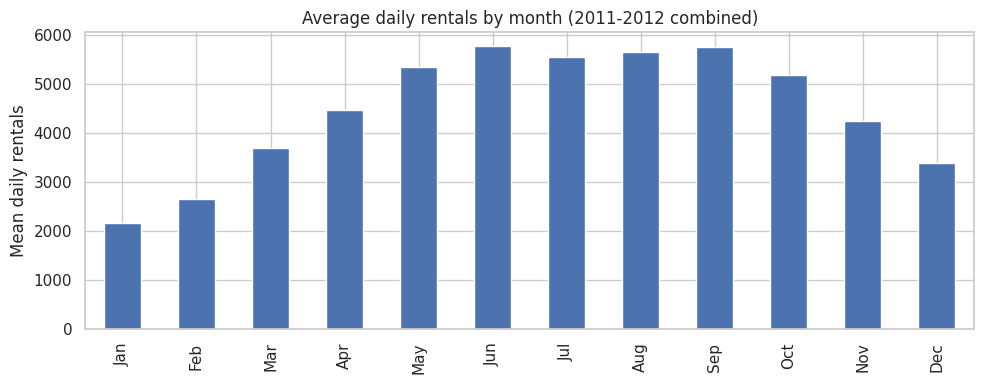

In [3]:
by_month = df.groupby(df.index.month)["cnt"].mean().round(0)
by_month.index = ["Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec"]

ax = by_month.plot(kind="bar", figsize=(10, 4),
                   title="Average daily rentals by month (2011-2012 combined)")
ax.set_ylabel("Mean daily rentals")
ax.set_xlabel("")
plt.tight_layout()

June and September are essentially tied for the peak, both averaging around 5,760 daily rentals. January is the lowest at around 2,200. The shoulder months (April, May, October, November) sit in between and show the steepest transitions. This chart confirms the seasonal story visible in the time-series plots, but now with precise monthly averages rather than a general shape.

## Average rentals by day of week

The same groupby pattern works for day of week. The pattern here is different from the monthly one because two types of riders are mixed together: regular commuters (registered users who are most active on weekdays) and recreational riders (casual users who favor weekends).

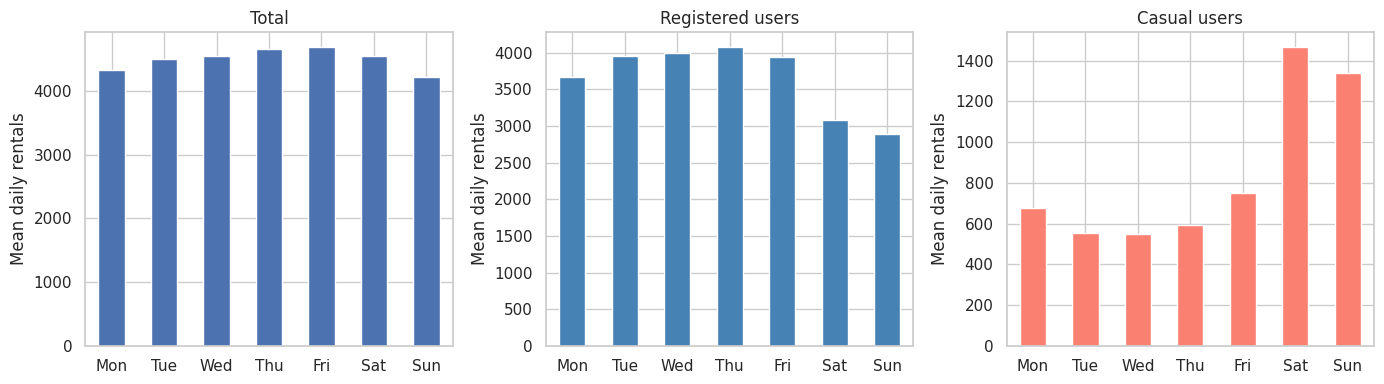

In [4]:
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Groupby on dayofweek (0=Mon)
by_dow = df.groupby(df.index.dayofweek)[["cnt", "casual", "registered"]].mean().round(0)
by_dow.index = day_order

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
by_dow["cnt"].plot(kind="bar", ax=axes[0], title="Total")
by_dow["registered"].plot(kind="bar", ax=axes[1], title="Registered users", color="steelblue")
by_dow["casual"].plot(kind="bar", ax=axes[2], title="Casual users", color="salmon")

for ax in axes:
    ax.set_ylabel("Mean daily rentals")
    ax.set_xticklabels(day_order, rotation=0)
plt.tight_layout()

The total chart is comparatively flat, ranging only about 11 percent from its Sunday low to its Friday high, because the two user types pull in opposite directions. Registered users (middle chart) peak Tuesday through Thursday, the core commuting days. Casual users (right chart) peak on Saturday and Sunday. The total stays nearly level because the commuter peak and the recreational peak roughly cancel each other out. You would never have seen this by looking only at the total; separating the two user types reveals the story.

## A two-dimensional view: month and day of week

The monthly and day-of-week patterns interact. Summer weekends might be especially busy while winter weekends are quiet. A pivot table captures the combination, and a heatmap makes it readable.

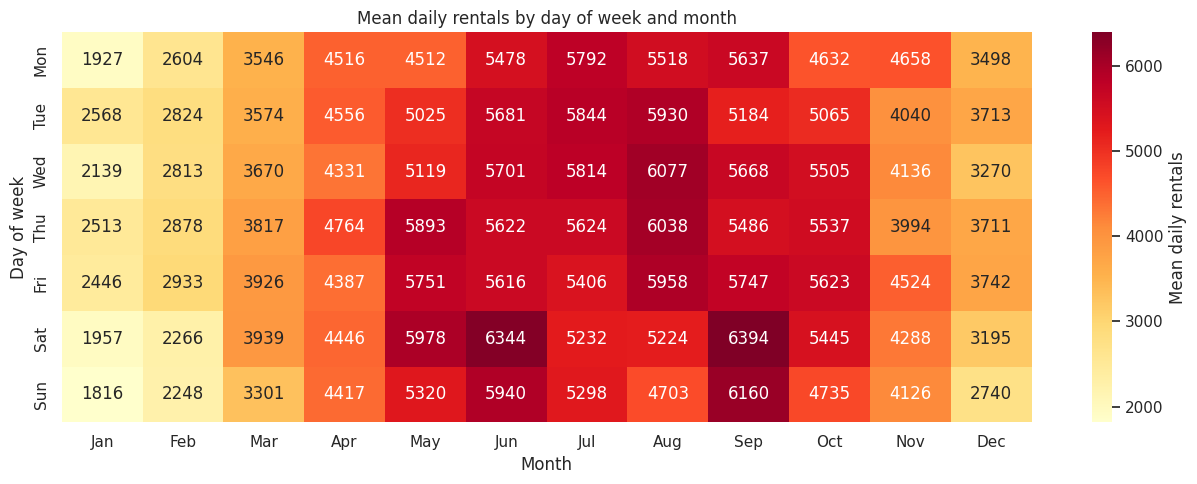

In [5]:
pivot = df.pivot_table(values="cnt",
                       index=df.index.dayofweek,
                       columns=df.index.month,
                       aggfunc="mean")

pivot.index = day_order
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "Mean daily rentals"})
ax.set_title("Mean daily rentals by day of week and month")
ax.set_xlabel("Month")
ax.set_ylabel("Day of week")
plt.tight_layout()

The hottest cell is September on Saturday, at roughly 6,400 mean daily rentals, followed closely by June on Saturday. Weekdays in August and September are also very warm, driven by registered commuters riding in good weather. The coldest cells are January and February on all days. The heatmap makes visible something that neither the monthly bar chart nor the day-of-week bar chart could show on its own: the interaction between the two patterns. Summer weekends are dominated by casual riders; fall weekdays are dominated by commuters.

## The completed tool table

Grouping by time components adds the final row to the reference table we have been growing since notebook 11.2. Four tools, four different questions:

| Question you are asking | Tool | What you keep | What you lose |
|---|---|---|---|
| What was the total or typical value per week, month, or year? | `resample("ME").sum()` or `.mean()` | A clean summary at the new resolution | The daily rows themselves |
| What is the underlying trend, without giving up the daily rows? | `.rolling(7).mean()` | Every row, with the same index as the original | The first $n-1$ values become NaN, and the line lags sudden changes |
| How fast is it changing, compared to last period or last year? | `.diff()`, `.pct_change()`, `.pct_change(12)` | One change value per period, same index | The level itself, and the first `periods` values become NaN |
| Which month or weekday is reliably the busiest? | `groupby(df.index.month)`, `pivot_table` on time components | The recurring calendar pattern | The time order itself: which year or date each value came from |

When a new time-series question comes up, start by asking which row it belongs to. The hardest part of time-series work is rarely the syntax; it is recognizing which question you are actually asking.

## Module 11 complete

You have worked through the core toolkit for time series exploration. Notebook 11.1 showed how to parse dates and build a DatetimeIndex. Notebook 11.2 introduced resampling to change time resolution. Notebook 11.3 added rolling windows for overlaid trend lines. Notebook 11.4 used `.diff()` and `.pct_change()` to measure the rate and direction of change. This notebook read time components from the index and used groupby to find repeating seasonal structures. The exercises in notebook 11.9 give you practice combining all of these tools on the same dataset.

This is also the end of the course. Over the past eleven modules you built a complete data science workflow from scratch: loading and cleaning raw data, exploring it visually, aggregating it with groupby and SQL, and now detecting patterns in time. The tools change at each stage, but the underlying question is always the same: what does this data tell us, and how confident can we be? That question does not go away when the course ends. The datasets get larger, the questions get harder, and the tools keep changing. What stays constant is the habit of asking it.